Considere o seguinte sistema dinâmico não linear:

$$\dot{x} = -y-z$$

$$\dot{y} = x+ay$$

$$\dot{z} = b+ z(x-c)$$

Simule a evolução temporal dos estados deste sistema para 1000s, considerando os parâmetros b=2, c=4. Use o comando plot3. Use como condições iniciais (x,y,z) os seus 3 últimos algarismos do número de matrícula. Ex: matrícula 123456789 implica em (x,y,z) = (7,8,9). Além disso, considera o parâmetro $a = \dfrac{0,3}{9}x + 0,13$. Ex: matrícula 123456789 implica em a=0,3633.

Copie o código feito para a caixa de diálogo a seguir.

Valor de a = 0.1300


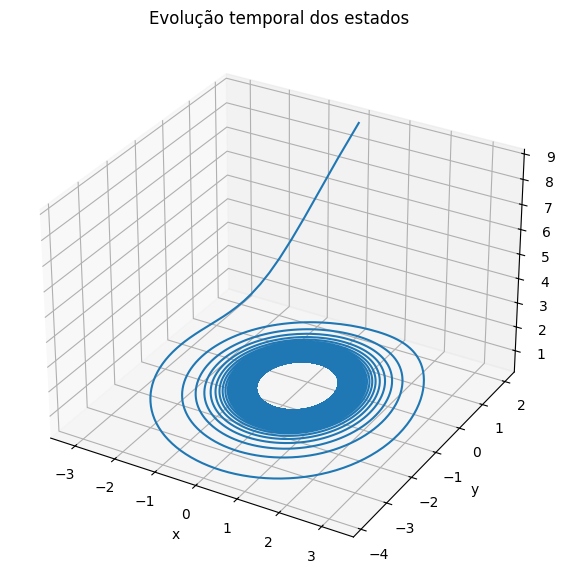

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Parâmetros do sistema
b = 2
c = 4

# Matrícula: 2024056029
# Últimos 3 algarismos -> (x, y, z) = (0, 2, 9)
x0 = 0
y0 = 2
z0 = 9

# Cálculo do parâmetro a
# a = (0.3/9)*x + 0.13
a = (0.3 / 9) * x0 + 0.13

print(f"Valor de a = {a:.4f}")

# Sistema dinâmico não linear
def sistema(t, estado):
    x, y, z = estado
    
    dxdt = -y - z
    dydt = x + a * y
    dzdt = b + z * (x - c)
    
    return [dxdt, dydt, dzdt]

# Intervalo de simulação
t_inicial = 0
t_final = 1000

# Pontos de avaliação
t_eval = np.linspace(t_inicial, t_final, 20000)

# Resolver o sistema
sol = solve_ivp(
    sistema,
    [t_inicial, t_final],
    [x0, y0, z0],
    t_eval=t_eval
)

# Extraindo resultados
x = sol.y[0]
y = sol.y[1]
z = sol.y[2]

# Gráfico 3D equivalente ao plot3 do MATLAB
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(x, y, z)

ax.set_title("Evolução temporal dos estados")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

plt.show()